# Multitask Evaluation: Graph + Node Classification

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append('../')
print(sys.path[-3:])

['', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/site-packages', '../']


In [2]:
import os
import json
import math
import random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
)
from sklearn.manifold import TSNE

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from networks.graph_attention_ffn_kan_multitask_updated import GraphAttentionKAN

plt.rcParams["figure.figsize"] = (8, 5)
# sns.set_context("notebook")

In [3]:
# ========= CONFIG =========
PROJECT_ROOT = Path("..").resolve()

GRAPH_FOLDER = PROJECT_ROOT / "data/2017-subaru-forester/graphs_subsample_node_classification_v2"
CKPT_PATH = PROJECT_ROOT / "save/graph_attention_ffn_kan_multitask_turning/graph_attention_ffn_kan_multitask_turning_best_joint.pth"

SPLIT = "test"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 128
NUM_WORKERS = 8
MAX_SHARDS = 0      # 0 = load all shards
MAX_SAMPLES = 0     # 0 = use all graphs in split

# node task config
NODE_TARGET_OVERRIDE = None   # None -> lấy từ ckpt['args']['node_target']; hoặc đặt 'node_y' / 'node_is_attack'
PRINT_TOP_NODE_ERRORS = 20

# t-SNE config
TSNE_MAX_POINTS = 3000
TSNE_PERPLEXITY = 30
TSNE_RANDOM_STATE = 42

print("GRAPH_FOLDER:", GRAPH_FOLDER)
print("CKPT_PATH   :", CKPT_PATH)
print("DEVICE      :", DEVICE)
print("graph exists:", GRAPH_FOLDER.exists())
print("ckpt exists :", CKPT_PATH.exists())

GRAPH_FOLDER: /home/hieutt/MRGA-KAN/data/2017-subaru-forester/graphs_subsample_node_classification_v2
CKPT_PATH   : /home/hieutt/MRGA-KAN/save/graph_attention_ffn_kan_multitask_turning/graph_attention_ffn_kan_multitask_turning_best_joint.pth
DEVICE      : cuda
graph exists: True
ckpt exists : True


In [4]:

# ========= HELPERS =========
def load_table(base: Path) -> pd.DataFrame:
    pq = base.with_suffix(".parquet")
    csv = base.with_suffix(".csv")
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"Cannot find {pq} or {csv}")


def infer_label_mapping(graph_folder: Path) -> Dict[int, str]:
    mapping = {}
    for split in ["train", "val", "test"]:
        try:
            df = load_table(graph_folder / f"graph_index_{split}")
            if "y" in df.columns and "window_label" in df.columns:
                pairs = df[["y", "window_label"]].drop_duplicates()
                for _, row in pairs.iterrows():
                    mapping[int(row["y"])] = str(row["window_label"])
        except Exception:
            continue
    if not mapping:
        raise RuntimeError("Could not infer label mapping from graph_index files.")
    return dict(sorted(mapping.items(), key=lambda kv: kv[0]))


def graph_dict_to_data(graph: dict, fallback_graph_id: Optional[str] = None) -> Data:
    data = Data(
        x=graph["x"].float(),
        edge_index=graph["edge_index"].long(),
        edge_attr=graph["edge_attr"].float(),
        edge_type=graph["edge_type"].long(),
        id_token=graph["id_index"].long(),
        y=graph["y"].view(-1).long(),
    )

    if "node_y" in graph:
        data.node_y = graph["node_y"].long()
    if "node_mask" in graph:
        data.node_mask = graph["node_mask"].bool()
    if "node_is_attack" in graph:
        data.node_is_attack = graph["node_is_attack"].long()

    meta = graph.get("meta", {})
    data.attack_count = torch.tensor([int(meta.get("attack_count", 0))], dtype=torch.long)
    data.attack_ratio = torch.tensor([float(meta.get("attack_ratio", 0.0))], dtype=torch.float32)
    data.is_mixed_window = torch.tensor([int(bool(meta.get("is_mixed_window", False)))], dtype=torch.long)

    graph_id = graph.get("graph_id", fallback_graph_id if fallback_graph_id is not None else "unknown_graph")
    label_name = graph.get("window_label", None)
    data.graph_id = graph_id
    data.window_label = label_name if label_name is not None else None
    return data


def load_graph_split(
    graph_folder: Path,
    split_name: str,
    max_shards: int = 0,
    max_samples: int = 0,
) -> List[Data]:
    split_dir = graph_folder / split_name
    shard_paths = sorted(split_dir.glob(f"graphs_{split_name}_shard*.pt"))
    if len(shard_paths) == 0:
        raise FileNotFoundError(f"No shard files found in {split_dir}")
    if max_shards > 0:
        shard_paths = shard_paths[:max_shards]

    dataset: List[Data] = []
    count = 0
    for shard_path in shard_paths:
        shard_graphs = torch.load(shard_path, map_location="cpu", weights_only=False)
        for i, g in enumerate(shard_graphs):
            fallback_graph_id = f"{split_name}:{shard_path.stem}:{i}"
            dataset.append(graph_dict_to_data(g, fallback_graph_id=fallback_graph_id))
            count += 1
            if max_samples > 0 and count >= max_samples:
                return dataset
    return dataset


def build_model_from_ckpt(
    ckpt: dict,
    num_classes: int,
    num_node_classes: int,
    num_ids: int,
    sample_data: Data,
    device: str = "cpu",
):
    args = ckpt.get("args", {})

    model = GraphAttentionKAN(
        node_feat_dim=sample_data.x.size(1),
        edge_attr_dim=sample_data.edge_attr.size(1),
        num_classes=num_classes,
        num_node_classes=num_node_classes,
        num_ids=num_ids,
        hidden_dim=args.get("hidden_dim", 128),
        num_layers=args.get("num_layers", 3),
        heads=args.get("heads", 4),
        id_emb_dim=args.get("id_emb_dim", 32),
        rel_emb_dim=args.get("rel_emb_dim", 8),
        num_relations=args.get("num_relations", 4),
        dropout=args.get("dropout", 0.2),
        ffn_ratio=args.get("ffn_ratio", 2.0),

        block_kan_grid_size=args.get("block_kan_grid_size", 5),
        block_kan_spline_order=args.get("block_kan_spline_order", 3),
        block_kan_scale_noise=args.get("block_kan_scale_noise", 0.1),
        block_kan_scale_base=args.get("block_kan_scale_base", 1.0),
        block_kan_scale_spline=args.get("block_kan_scale_spline", 1.0),

        kan_hidden=args.get("kan_hidden", 128),
        kan_grid_size=args.get("kan_grid_size", 5),
        kan_spline_order=args.get("kan_spline_order", 3),
        kan_scale_noise=args.get("kan_scale_noise", 0.1),
        kan_scale_base=args.get("kan_scale_base", 1.0),
        kan_scale_spline=args.get("kan_scale_spline", 1.0),

        node_head_from_layer=args.get("node_head_from_layer", -1),
    ).to(device)

    missing, unexpected = model.load_state_dict(ckpt["model"], strict=False)
    print("Missing keys   :", missing[:10], "..." if len(missing) > 10 else "")
    print("Unexpected keys:", unexpected[:10], "..." if len(unexpected) > 10 else "")
    if len(missing) > 0 or len(unexpected) > 0:
        print("⚠️ Check your local model file if these are not expected.")
    model.eval()
    return model


@torch.no_grad()
def get_graph_embedding(model, data: Data, device: str = "cpu") -> torch.Tensor:
    model.eval()
    data = data.to(device)
    h = model.encode_nodes(data)
    batch = getattr(data, "batch", None)
    if batch is None:
        batch = torch.zeros(data.x.size(0), dtype=torch.long, device=data.x.device)
    g = model.readout(h, batch)
    return g


def _get_node_targets_and_mask(batch: Data, node_target: str):
    if not hasattr(batch, node_target):
        return None, None
    node_y = getattr(batch, node_target).view(-1).long()
    node_mask = getattr(batch, "node_mask", None)
    if node_mask is None:
        node_mask = torch.ones_like(node_y, dtype=torch.bool)
    else:
        node_mask = node_mask.view(-1).bool()
    return node_y, node_mask


@torch.no_grad()
def evaluate_multitask_model(
    model,
    loader,
    graph_label_mapping: Dict[int, str],
    node_target: str = "node_y",
    node_label_mapping: Optional[Dict[int, str]] = None,
    device: str = "cpu",
):
    model.eval()

    graph_y_true, graph_y_pred = [], []
    graph_probs_all = []
    graph_logits_all = []
    embeddings_all = []
    graph_ids = []

    node_y_true, node_y_pred = [], []

    for batch in loader:
        batch = batch.to(device)

        out = model(batch, return_graph_embedding=True, return_node_logits=True)

        if isinstance(out, dict):
            graph_logits = out["graph_logits"]
            node_logits = out.get("node_logits", None)
            graph_emb = out["graph_embedding"]
        else:
            raise RuntimeError("Expected model to return dict with graph_logits/node_logits/graph_embedding.")

        graph_probs = F.softmax(graph_logits, dim=1)
        graph_pred = graph_probs.argmax(dim=1)

        graph_y_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
        graph_y_pred.extend(graph_pred.detach().cpu().numpy().tolist())
        graph_probs_all.append(graph_probs.detach().cpu().numpy())
        graph_logits_all.append(graph_logits.detach().cpu().numpy())
        embeddings_all.append(graph_emb.detach().cpu().numpy())

        gid = getattr(batch, "graph_id", None)
        if gid is None:
            graph_ids.extend([f"graph_{len(graph_ids)+i}" for i in range(batch.y.numel())])
        elif isinstance(gid, list):
            graph_ids.extend(gid)
        else:
            try:
                graph_ids.extend(list(gid))
            except Exception:
                graph_ids.extend([str(gid)] * batch.y.numel())

        if node_logits is not None:
            node_target_y, node_mask = _get_node_targets_and_mask(batch, node_target=node_target)
            if node_target_y is not None and node_mask is not None and node_mask.any():
                node_pred = node_logits[node_mask].argmax(dim=1)
                node_y_true.extend(node_target_y[node_mask].detach().cpu().numpy().tolist())
                node_y_pred.extend(node_pred.detach().cpu().numpy().tolist())

    graph_y_true = np.asarray(graph_y_true)
    graph_y_pred = np.asarray(graph_y_pred)
    graph_probs = np.concatenate(graph_probs_all, axis=0) if len(graph_probs_all) else np.empty((0, len(graph_label_mapping)))
    graph_logits = np.concatenate(graph_logits_all, axis=0) if len(graph_logits_all) else np.empty((0, len(graph_label_mapping)))
    graph_embs = np.concatenate(embeddings_all, axis=0) if len(embeddings_all) else np.empty((0, 1))

    graph_metrics = {
        "acc": accuracy_score(graph_y_true, graph_y_pred),
        "macro_f1": f1_score(graph_y_true, graph_y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(graph_y_true, graph_y_pred, average="weighted", zero_division=0),
        "balanced_acc": balanced_accuracy_score(graph_y_true, graph_y_pred),
    }

    if len(node_y_true) > 0:
        node_y_true = np.asarray(node_y_true)
        node_y_pred = np.asarray(node_y_pred)
        node_metrics = {
            "acc": accuracy_score(node_y_true, node_y_pred),
            "macro_f1": f1_score(node_y_true, node_y_pred, average="macro", zero_division=0),
            "weighted_f1": f1_score(node_y_true, node_y_pred, average="weighted", zero_division=0),
            "balanced_acc": balanced_accuracy_score(node_y_true, node_y_pred),
        }
    else:
        node_y_true = np.asarray([])
        node_y_pred = np.asarray([])
        node_metrics = {
            "acc": 0.0,
            "macro_f1": 0.0,
            "weighted_f1": 0.0,
            "balanced_acc": 0.0,
        }

    return {
        "graph": {
            "metrics": graph_metrics,
            "y_true": graph_y_true,
            "y_pred": graph_y_pred,
            "probs": graph_probs,
            "logits": graph_logits,
            "embeddings": graph_embs,
            "graph_ids": graph_ids,
        },
        "node": {
            "metrics": node_metrics,
            "y_true": node_y_true,
            "y_pred": node_y_pred,
            "label_mapping": node_label_mapping,
        },
    }


def report_dataframe(y_true, y_pred, label_mapping: Dict[int, str]) -> pd.DataFrame:
    labels = sorted(label_mapping.keys())
    target_names = [label_mapping[i] for i in labels]
    report = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        digits=4
    )
    return report


def draw_confusion_matrix(cm, classes, save_dir=None, vmax=10000):
    cm_df = pd.DataFrame(cm,
                     index = classes, 
                     columns = classes)
    mask = np.zeros_like(cm)
    np.fill_diagonal(mask, 1)
    plt.figure(figsize=(10,8))
    # sns.heatmap(cm_df, fmt='d', annot=True, cmap='YlGnBu', cbar=False, linewidths=0.5)
    sns.heatmap(cm_df, fmt='d', annot=True, cmap='YlGnBu', cbar=False, 
            linewidths=0.5, vmin=0, vmax=vmax)
    plt.xticks(rotation=45, ha='right')
    plt.title('Confusion Matrix - MRGAT-KAN(Full model)')
    plt.ylabel('Actual Values')
    plt.xlabel('Predicted Values')
    # if save_dir is not None:
    #     plt.savefig(save_dir.format(ckpt_epoch), dpi=300, bbox_inches="tight", pad_inches=0.5)
    plt.show()


def run_tsne(embeddings: np.ndarray, max_points: int = 3000, perplexity: int = 30, random_state: int = 42):
    if len(embeddings) == 0:
        raise ValueError("No embeddings to visualize.")
    n = len(embeddings)
    if max_points > 0 and n > max_points:
        rng = np.random.default_rng(random_state)
        keep_idx = np.sort(rng.choice(n, size=max_points, replace=False))
        emb = embeddings[keep_idx]
    else:
        keep_idx = np.arange(n)
        emb = embeddings

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, len(emb) - 1)),
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    emb2d = tsne.fit_transform(emb)
    return emb2d, keep_idx


def plot_tsne_embeddings(emb2d, y_true, y_pred, label_mapping, title="t-SNE of graph embeddings", figsize=(10, 8)):
    labels = sorted(label_mapping.keys())
    colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

    plt.figure(figsize=figsize)
    for c, color in zip(labels, colors):
        mask = (y_true == c)
        if mask.sum() == 0:
            continue
        plt.scatter(
            emb2d[mask, 0],
            emb2d[mask, 1],
            s=16,
            alpha=0.75,
            color=color,
            label=label_mapping[c],
        )
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
    plt.tight_layout()
    plt.show()


def misclassified_table(y_true, y_pred, probs, graph_ids, label_mapping, top_n=20):
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        return pd.DataFrame(columns=["graph_id", "true_label", "pred_label", "pred_confidence"])

    pred_conf = probs[wrong, y_pred[wrong]]
    order = np.argsort(-pred_conf)

    rows = []
    for idx in wrong[order][:top_n]:
        rows.append({
            "graph_id": graph_ids[idx],
            "true_label": label_mapping[int(y_true[idx])],
            "pred_label": label_mapping[int(y_pred[idx])],
            "pred_confidence": float(probs[idx, y_pred[idx]]),
        })
    return pd.DataFrame(rows)


def node_error_table(y_true, y_pred, label_mapping, top_n=20):
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        return pd.DataFrame(columns=["true_label", "pred_label", "count"])

    pairs = pd.DataFrame({
        "true_label": [label_mapping[int(v)] for v in y_true[wrong]],
        "pred_label": [label_mapping[int(v)] for v in y_pred[wrong]],
    })
    tbl = pairs.value_counts().reset_index(name="count")
    return tbl.head(top_n)


In [5]:
# ========= LOAD DATA =========
ckpt_preview = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
ckpt_args = ckpt_preview.get("args", {})

label_mapping = infer_label_mapping(GRAPH_FOLDER)
label_names = [label_mapping[i] for i in sorted(label_mapping)]

node_target = NODE_TARGET_OVERRIDE if NODE_TARGET_OVERRIDE is not None else ckpt_args.get("node_target", "node_y")
if node_target == "node_is_attack":
    node_label_mapping = {0: "normal", 1: "attack"}
    num_node_classes = 2
else:
    node_label_mapping = label_mapping.copy()
    num_node_classes = len(node_label_mapping)

test_dataset = load_graph_split(
    GRAPH_FOLDER,
    split_name=SPLIT,
    max_shards=MAX_SHARDS,
    max_samples=MAX_SAMPLES,
)

print("Loaded test graphs:", len(test_dataset))
print("num graph classes :", len(label_mapping))
print("graph label mapping:", label_mapping)
print("node_target       :", node_target)
print("num node classes  :", num_node_classes)
print("node label mapping:", node_label_mapping)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)

Loaded test graphs: 31538
num graph classes : 10
graph label mapping: {0: 'normal', 1: 'combined', 2: 'dos', 3: 'fuzzing', 4: 'gear', 5: 'interval', 6: 'rpm', 7: 'speed', 8: 'standstill', 9: 'systematic'}
node_target       : node_y
num node classes  : 10
node label mapping: {0: 'normal', 1: 'combined', 2: 'dos', 3: 'fuzzing', 4: 'gear', 5: 'interval', 6: 'rpm', 7: 'speed', 8: 'standstill', 9: 'systematic'}


In [6]:
# ========= LOAD CHECKPOINT + BUILD MODEL =========
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
print("Checkpoint keys:", ckpt.keys())

num_classes = len(label_mapping)

# infer num_ids from dataset
num_ids = 0
for d in test_dataset:
    num_ids = max(num_ids, int(d.id_token.max().item()))
num_ids = int(num_ids) + 1

sample_data = test_dataset[0]
model = build_model_from_ckpt(
    ckpt=ckpt,
    num_classes=num_classes,
    num_node_classes=num_node_classes,
    num_ids=num_ids,
    sample_data=sample_data,
    device=DEVICE,
)

print("num_ids         :", num_ids)
print("sample x dim    :", sample_data.x.shape)
print("sample edge dim :", sample_data.edge_attr.shape)

Checkpoint keys: dict_keys(['epoch', 'model', 'optimizer', 'scheduler', 'scaler', 'best_val_selection', 'best_test_selection', 'best_val_graph_macro_f1', 'best_test_graph_macro_f1', 'best_val_node_macro_f1', 'best_test_node_macro_f1', 'history', 'label_mapping', 'node_label_mapping', 'args'])
Missing keys   : [] 
Unexpected keys: [] 
num_ids         : 1568
sample x dim    : torch.Size([64, 16])
sample edge dim : torch.Size([636, 6])


## Run evaluation

In [7]:
import numpy as np

def compute_fnr_percent(y_true, y_pred, normal_class=0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    true_attack = (y_true != normal_class)
    pred_attack = (y_pred != normal_class)

    fn = np.sum(true_attack & (~pred_attack))   # attack -> normal
    tp = np.sum(true_attack & pred_attack)      # attack -> attack

    denom = tp + fn
    if denom == 0:
        return 0.0

    return fn / denom * 100.0

In [8]:
outputs = evaluate_multitask_model(
    model=model,
    loader=test_loader,
    graph_label_mapping=label_mapping,
    node_target=node_target,
    node_label_mapping=node_label_mapping,
    device=DEVICE,
)

graph_out = outputs["graph"]
node_out = outputs["node"]

graph_metrics = graph_out["metrics"]
node_metrics = node_out["metrics"]

graph_fnr = compute_fnr_percent(
    graph_out["y_true"],
    graph_out["y_pred"],
    normal_class=0
)

node_fnr = compute_fnr_percent(
    node_out["y_true"],
    node_out["y_pred"],
    normal_class=0
)

print("=== GRAPH CLASSIFICATION ===")
print("ACC         :", f"{graph_metrics['acc']*100:.2f}%")
print("Macro-F1    :", f"{graph_metrics['macro_f1']:.4f}")
print("Weighted-F1 :", f"{graph_metrics['weighted_f1']:.4f}")
print("Balanced Acc:", f"{graph_metrics['balanced_acc']:.4f}")
print("FNR (%)     :", f"{graph_fnr:.4f}%")
print("Embeddings  :", graph_out["embeddings"].shape)

# ===  FNR PER CLASS ===
graph_classes = ['Normal', 'Combined', 'DoS', 'Fuzzy', 'Gear', 'Interval', 'RPM', 'Speed', 'Standstill', 'Systematic']
y_true_g = np.array(graph_out["y_true"])
y_pred_g = np.array(graph_out["y_pred"])

print("-" * 30)
print("Graph FNR per class:")
for i, cls_name in enumerate(graph_classes):
    # Tìm các sample có nhãn thực tế là i
    mask = (y_true_g == i)
    total_actual = np.sum(mask)
    
    if total_actual > 0:
        # False Negatives: Thực tế là i nhưng model dự đoán khác i
        fn = np.sum((y_true_g == i) & (y_pred_g != i))
        fnr_cls = (fn / total_actual) * 100
        print(f"  {cls_name:<12}: {fnr_cls:>7.4f}% (FN: {fn}/{total_actual})")
    else:
        print(f"  {cls_name:<12}:     N/A (0 samples)")
print("-" * 30)
# ==========================================

print("\n=== NODE CLASSIFICATION ===")
print("ACC         :", f"{node_metrics['acc']*100:.2f}%")
print("Macro-F1    :", f"{node_metrics['macro_f1']:.4f}")
print("Weighted-F1 :", f"{node_metrics['weighted_f1']:.4f}")
print("Balanced Acc:", f"{node_metrics['balanced_acc']:.4f}")
print("FNR (%)     :", f"{node_fnr:.4f}%")
print("Node samples:", len(node_out["y_true"]))

# ===  FNR PER CLASS ===
node_classes = ['Normal', 'Combined', 'DoS', 'Fuzzy', 'Gear', 'Interval', 'RPM', 'Speed', 'Standstill', 'Systematic']
y_true_n = np.array(node_out["y_true"])
y_pred_n = np.array(node_out["y_pred"])

print("-" * 30)
print("Node FNR per class:")
for i, cls_name in enumerate(node_classes):
    # Tìm các sample có nhãn thực tế là i
    mask = (y_true_n == i)
    total_actual = np.sum(mask)
    
    if total_actual > 0:
        # False Negatives: Thực tế là i nhưng model dự đoán khác i
        fn = np.sum((y_true_n == i) & (y_pred_n != i))
        fnr_cls = (fn / total_actual) * 100
        print(f"  {cls_name:<12}: {fnr_cls:>7.4f}% (FN: {fn}/{total_actual})")
    else:
        print(f"  {cls_name:<12}:     N/A (0 samples)")
print("-" * 30)
# ==========================================

=== GRAPH CLASSIFICATION ===
ACC         : 99.84%
Macro-F1    : 0.9985
Weighted-F1 : 0.9984
Balanced Acc: 0.9985
FNR (%)     : 0.1194%
Embeddings  : (31538, 256)
------------------------------
Graph FNR per class:
  Normal      :  0.2006% (FN: 28/13957)
  Combined    :  0.1795% (FN: 8/4457)
  DoS         :  0.0000% (FN: 0/667)
  Fuzzy       :  0.1157% (FN: 1/864)
  Gear        :  0.0000% (FN: 0/704)
  Interval    :  0.0000% (FN: 0/6363)
  RPM         :  0.2259% (FN: 3/1328)
  Speed       :  0.2509% (FN: 4/1594)
  Standstill  :  0.0000% (FN: 0/617)
  Systematic  :  0.5066% (FN: 5/987)
------------------------------

=== NODE CLASSIFICATION ===
ACC         : 99.97%
Macro-F1    : 0.9962
Weighted-F1 : 0.9997
Balanced Acc: 0.9966
FNR (%)     : 0.3525%
Node samples: 2018432
------------------------------
Node FNR per class:
  Normal      :  0.0205% (FN: 399/1947803)
  Combined    :  0.7248% (FN: 123/16970)
  DoS         :  0.0391% (FN: 4/10232)
  Fuzzy       :  0.6232% (FN: 46/7381)
  Gear  

## Graph classification report

In [9]:
graph_report_df = report_dataframe(
    graph_out["y_true"],
    graph_out["y_pred"],
    label_mapping,
)

print("Graphh Classification Report: MRGAT KAN-KAN\n", graph_report_df)


Graphh Classification Report: MRGAT KAN-KAN
               precision    recall  f1-score   support

      normal     0.9985    0.9980    0.9982     13957
    combined     0.9966    0.9982    0.9974      4457
         dos     1.0000    1.0000    1.0000       667
     fuzzing     0.9977    0.9988    0.9983       864
        gear     0.9972    1.0000    0.9986       704
    interval     0.9997    1.0000    0.9998      6363
         rpm     0.9992    0.9977    0.9985      1328
       speed     0.9969    0.9975    0.9972      1594
  standstill     1.0000    1.0000    1.0000       617
  systematic     0.9990    0.9949    0.9970       987

    accuracy                         0.9984     31538
   macro avg     0.9985    0.9985    0.9985     31538
weighted avg     0.9984    0.9984    0.9984     31538



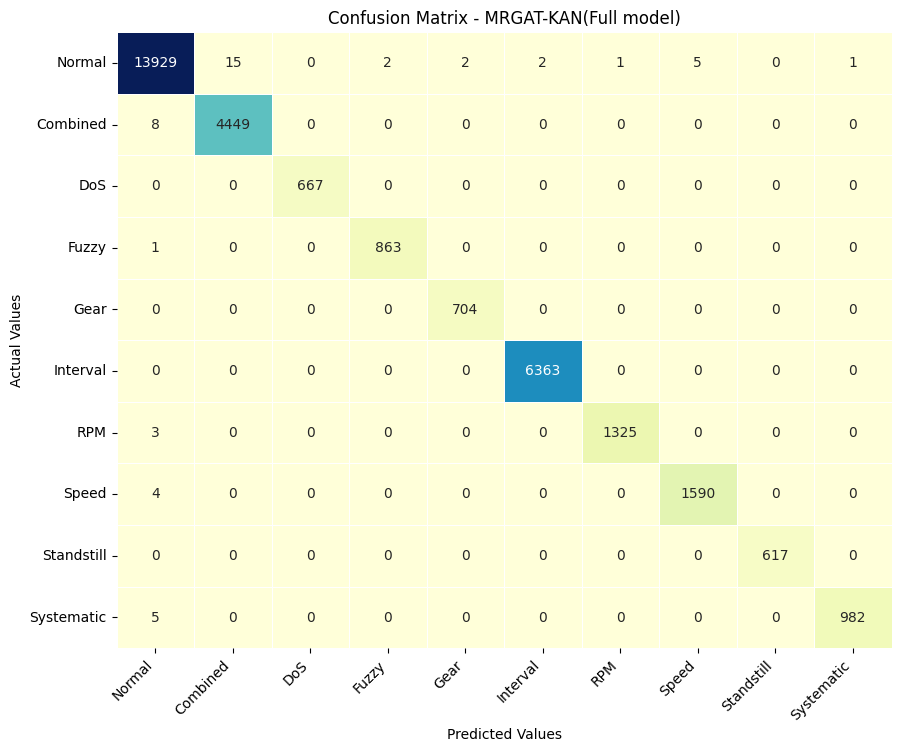

In [10]:
labels = sorted(label_mapping.keys())

graph_cm = confusion_matrix(graph_out["y_true"], graph_out["y_pred"], labels=labels)

draw_confusion_matrix(graph_cm, graph_classes)

## Node classification report

In [11]:
if len(node_out["y_true"]) == 0:
    print("No node predictions found. Check node_target / checkpoint / dataset fields.")
else:
    node_report_df = report_dataframe(
        node_out["y_true"],
        node_out["y_pred"],
        node_label_mapping,
    )
    print("Node Classification Report: MRGAT KAN-KAN\n", node_report_df)

    # node_classes = [node_label_mapping[i] for i in sorted(node_label_mapping.keys())]
    # node_cm = confusion_matrix(node_out["y_true"], node_out["y_pred"], labels=sorted(node_label_mapping.keys()))
    # draw_confusion_matrix(node_cm, node_classes, title=f"Node classification confusion matrix ({node_target})", figsize=(10, 8))

Node Classification Report: MRGAT KAN-KAN
               precision    recall  f1-score   support

      normal     0.9999    0.9998    0.9998   1947803
    combined     0.9832    0.9928    0.9879     16970
         dos     1.0000    0.9996    0.9998     10232
     fuzzing     0.9955    0.9938    0.9946      7381
        gear     0.9989    1.0000    0.9995       914
    interval     0.9996    1.0000    0.9998     21102
         rpm     0.9917    0.9982    0.9950      3356
       speed     0.9932    0.9937    0.9934      3649
  standstill     1.0000    1.0000    1.0000      2181
  systematic     0.9948    0.9886    0.9917      4844

    accuracy                         0.9997   2018432
   macro avg     0.9957    0.9966    0.9962   2018432
weighted avg     0.9997    0.9997    0.9997   2018432



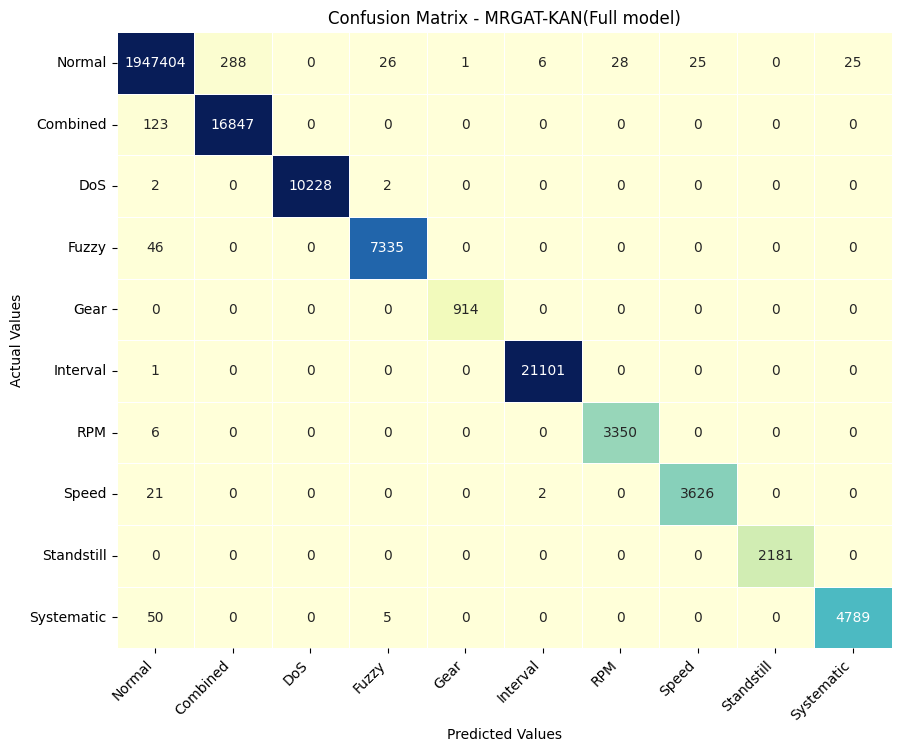

In [12]:
labels = sorted(label_mapping.keys())
node_classes = ['Normal', 'Combined', 'DoS', 'Fuzzy', 'Gear', 'Interval', 'RPM', 'Speed', 'Standstill', 'Systematic']
node_cm = confusion_matrix(node_out["y_true"], node_out["y_pred"], labels=labels)

draw_confusion_matrix(node_cm, node_classes)

## t-SNE of graph embeddings

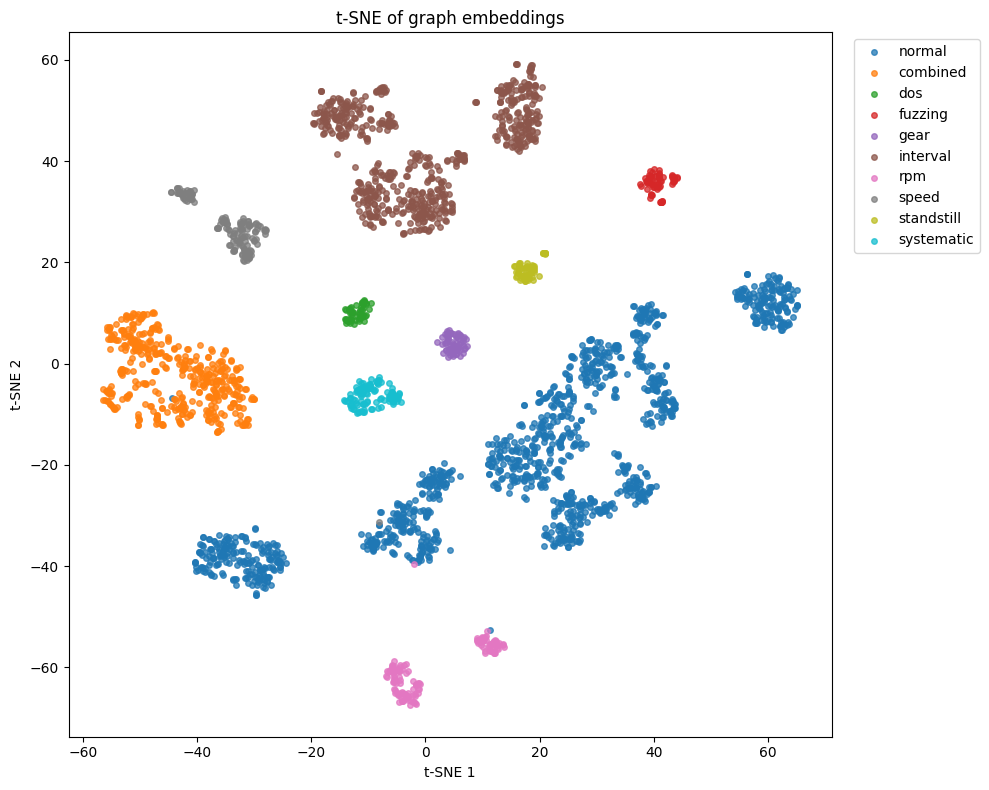

In [13]:
emb2d, kept_idx = run_tsne(
    graph_out["embeddings"],
    max_points=TSNE_MAX_POINTS,
    perplexity=TSNE_PERPLEXITY,
    random_state=TSNE_RANDOM_STATE,
)

y_true_tsne = graph_out["y_true"][kept_idx]
y_pred_tsne = graph_out["y_pred"][kept_idx]

plot_tsne_embeddings(
    emb2d=emb2d,
    y_true=y_true_tsne,
    y_pred=y_pred_tsne,
    label_mapping=label_mapping,
    title="t-SNE of graph embeddings",
    figsize=(10, 8),
)